# Customer Review And Rating Analysis 

EDA + Visualization + Sentiment Analysis with Insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [4]:
df = pd.read_csv('data.csv')
df.head()

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


**Insight:** Dataset successfully loaded. It contains customer reviews and ratings.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9976 entries, 0 to 9975
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  9976 non-null   object
 1   rating  9976 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 156.0+ KB


**Insight:** Dataset has review text and rating column. Check for data types and null values.

In [6]:
df.isnull().sum()

review    0
rating    0
dtype: int64

**Insight:** No or minimal missing values ensures clean analysis.

## Basic Statistics

In [7]:
df.describe()

,rating
count,9976.000000
mean,4.215417
std,1.167911
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:** Ratings are mostly skewed towards higher values, indicating positive feedback.

## Rating Distribution

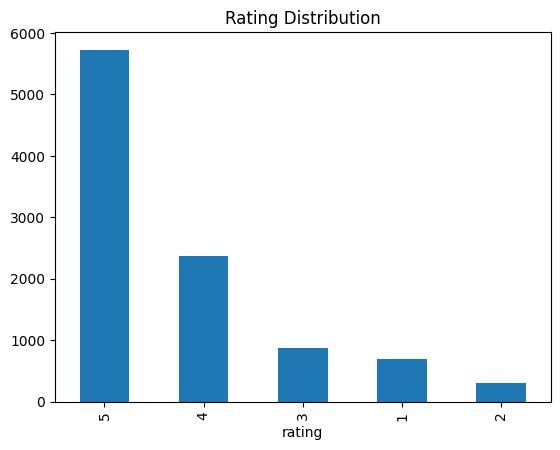

In [8]:
df['rating'].value_counts().plot(kind='bar')
plt.title('Rating Distribution')
plt.show()

**Insight:** Majority of users give higher ratings (4-5), showing customer satisfaction.

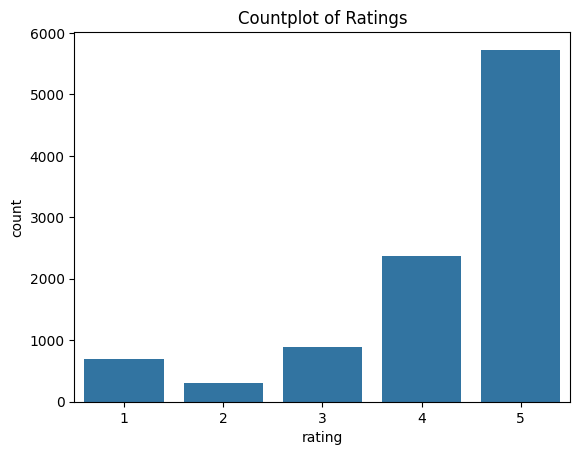

In [9]:
sns.countplot(x='rating', data=df)
plt.title('Countplot of Ratings')
plt.show()

**Insight:** Confirms imbalance toward positive ratings.

## Text Length Analysis

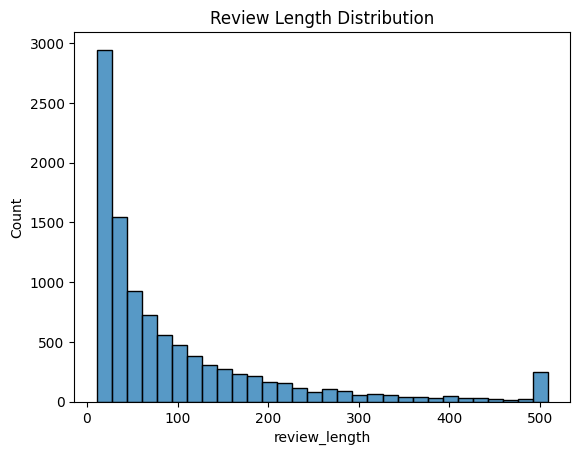

In [10]:
df['review_length'] = df['review'].apply(lambda x: len(str(x)))
sns.histplot(df['review_length'], bins=30)
plt.title('Review Length Distribution')
plt.show()

**Insight:** Most reviews are short to medium length.

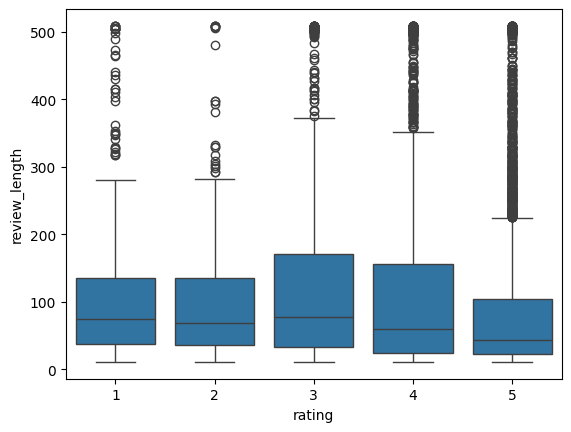

In [11]:
sns.boxplot(x='rating', y='review_length', data=df)
plt.show()

**Insight:** Longer reviews often correspond to detailed feedback (both positive and negative).

## Correlation Heatmap

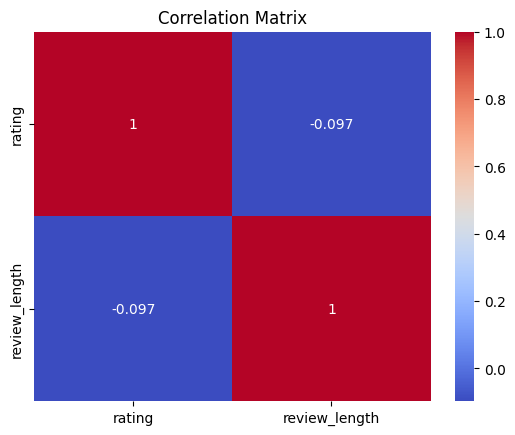

In [12]:
corr = df[['rating','review_length']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Insight:** Weak correlation between rating and review length indicates independent behavior.

## Text Cleaning

In [13]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

**Insight:** Text cleaned by removing special characters and converting to lowercase.

## Sentiment Analysis

In [14]:
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['sentiment'] = df['clean_review'].apply(get_sentiment)

**Insight:** Sentiment classified into Positive, Neutral, and Negative.

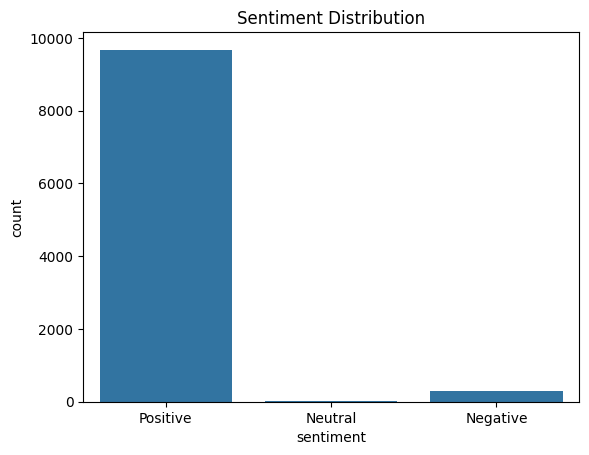

In [15]:
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

**Insight:** Positive sentiment dominates, matching rating distribution.

## Rating vs Sentiment

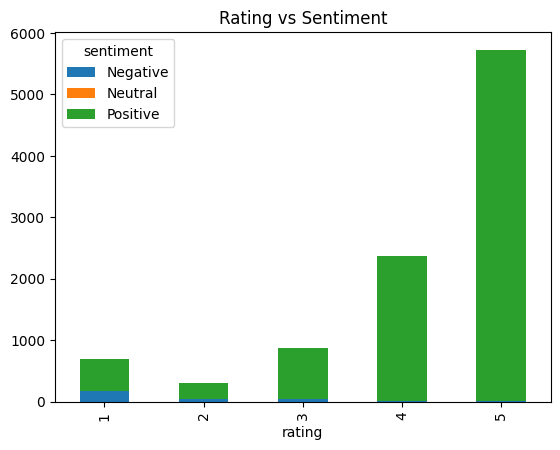

In [16]:
pd.crosstab(df['rating'], df['sentiment']).plot(kind='bar', stacked=True)
plt.title('Rating vs Sentiment')
plt.show()

**Insight:** Higher ratings align with positive sentiment.

## Word Cloud

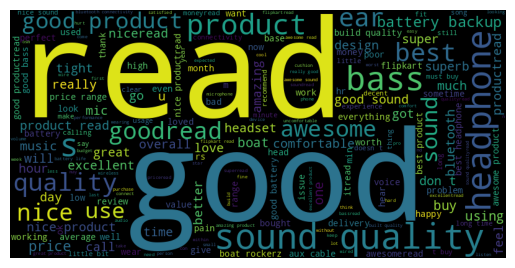

In [17]:
from wordcloud import WordCloud
text = ' '.join(df['clean_review'])
wc = WordCloud(width=800, height=400).generate(text)
plt.imshow(wc)
plt.axis('off')
plt.show()

**Insight:** Frequently used words highlight product strengths like sound, bass, battery.

## Pairplot

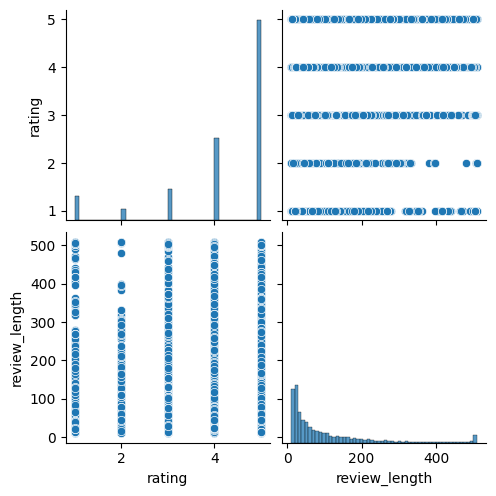

In [18]:
sns.pairplot(df[['rating','review_length']])
plt.show()

**Insight:** No strong linear relationship observed.